## Exploratory Data Analysis on S&P 500 Subset

This section provides an overview and basic statistics for the subset of S&P 500 companies (top 3 by weight in each sector).

In [15]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [16]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


In [17]:
sp500_subset.head()


,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [18]:
sectors_wgts.head()

,Symbol,Security,Sector,Weight
0,MMM,3M,Industrials,0.0015
1,AOS,A. O. Smith,Industrials,0.0002
2,ABT,Abbott Laboratories,Health Care,0.0037
3,ABBV,AbbVie,Health Care,0.0070
4,ACN,Accenture,Information Technology,0.0026


In [19]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

Price data shape: (41125, 10)

Columns in price data: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Security',
       'Sector', 'Weight'],
      dtype='object')

Date range:
Min: 2020-11-23 00:00:00 | Max: 2025-11-20 00:00:00

Number of symbols in price subset: 33

Missing values:
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [20]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

Weight data shape: (503, 4)

Columns in weight data: Index(['Symbol', 'Security', 'Sector', 'Weight'], dtype='object')
Number of sectors in weight dataset: 11

Missing values:
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [21]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

        Date      Close       High        Low       Open    Volume Symbol  \
0 2020-11-23  84.081802  84.559074  83.168406  83.884313   7541500   ABBV   
1 2020-11-24  85.546516  86.254193  84.410945  84.657805   9322200   ABBV   
2 2020-11-25  85.744026  85.957977  85.077496  85.431334   6368100   ABBV   
3 2020-11-27  86.311798  87.060621  85.826302  86.385860   4418800   ABBV   
4 2020-11-30  86.056725  86.747940  85.291446  86.501080  20726500   ABBV   

  Security       Sector  Weight  
0   AbbVie  Health Care   0.007  
1   AbbVie  Health Care   0.007  
2   AbbVie  Health Care   0.007  
3   AbbVie  Health Care   0.007  
4   AbbVie  Health Care   0.007  
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64
Symbols missing weights: []


In [22]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()
print(f"Total sum of weights in subset: {sum_weights*100:.2f}%")

Total sum of weights in subset: 49.96%


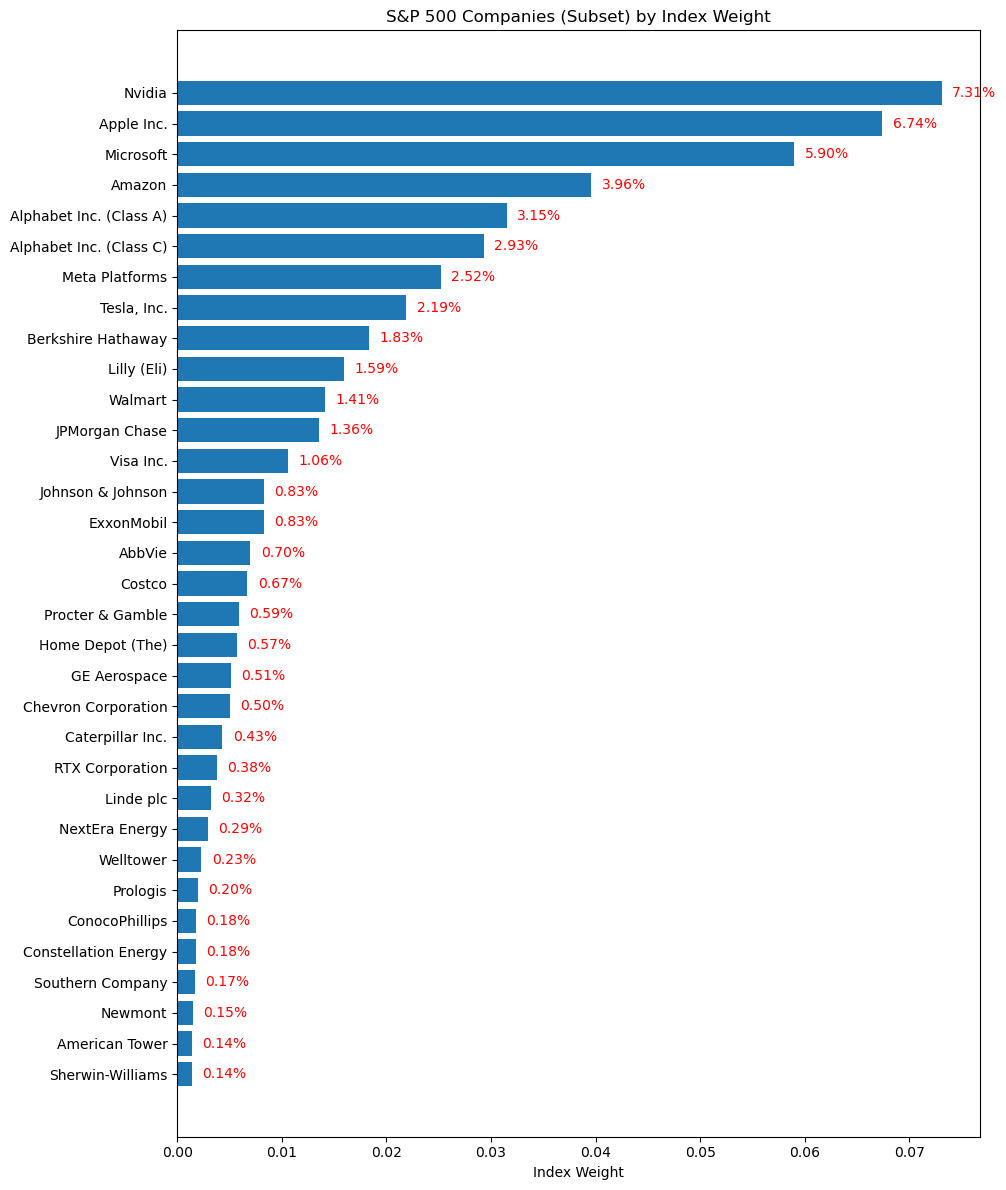

In [23]:
# Plot all S&P 500 Subset companies by weight with % labels

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Number of sectors to randomly include
X = 5   # <-- change this number to pick 5 sectors, or 3, or 8, etc.

# Get unique sectors
all_sectors = sorted(sp500_subset["Sector"].unique())

# Randomly pick X sectors
chosen_sectors = np.random.choice(all_sectors, size=X, replace=False)
print("Randomly selected sectors:", chosen_sectors)

# Filter to only those sectors
filtered = sp500_subset[sp500_subset["Sector"].isin(chosen_sectors)]

# Pick 1 random company for each chosen sector
unique_sec = filtered[["Symbol", "Sector"]].drop_duplicates()

selected_symbols = (
    unique_sec
    .groupby("Sector")["Symbol"]
    .apply(lambda x: np.random.choice(list(x), 1)[0])
)

print("\nRandomly selected companies from these sectors:")
print(selected_symbols)


Randomly selected sectors: ['Health Care' 'Communication Services' 'Real Estate' 'Utilities'
 'Consumer Staples']

Randomly selected companies from these sectors:
Sector
Communication Services    GOOGL
Consumer Staples            WMT
Health Care                 JNJ
Real Estate                 AMT
Utilities                   NEE
Name: Symbol, dtype: object


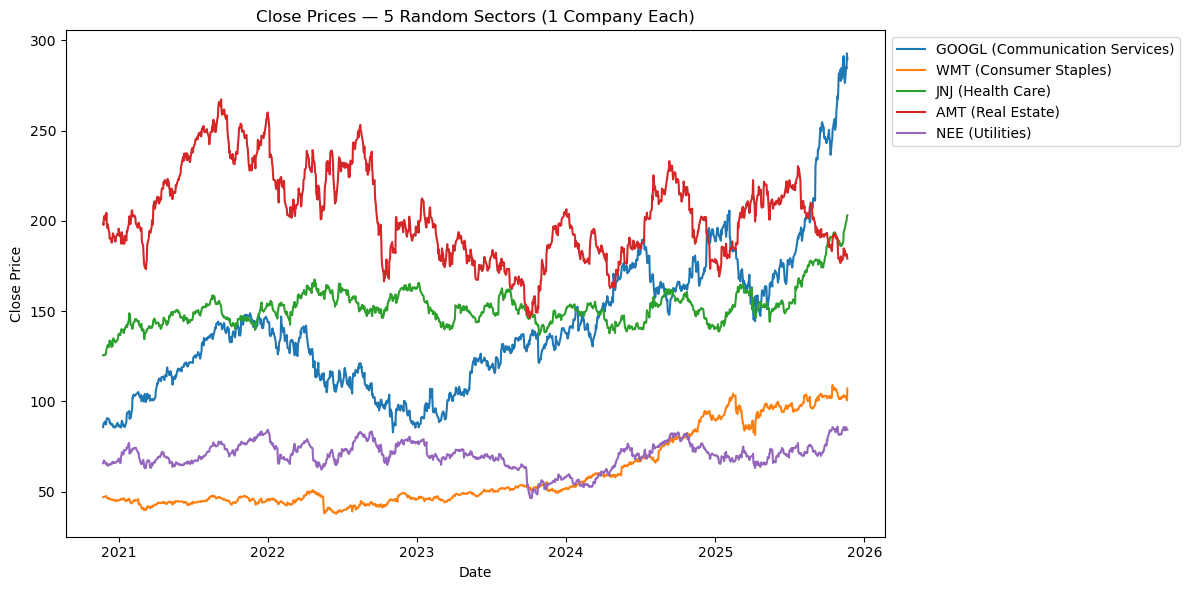

In [25]:
# Plot Close prices 

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Close"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Close Prices — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



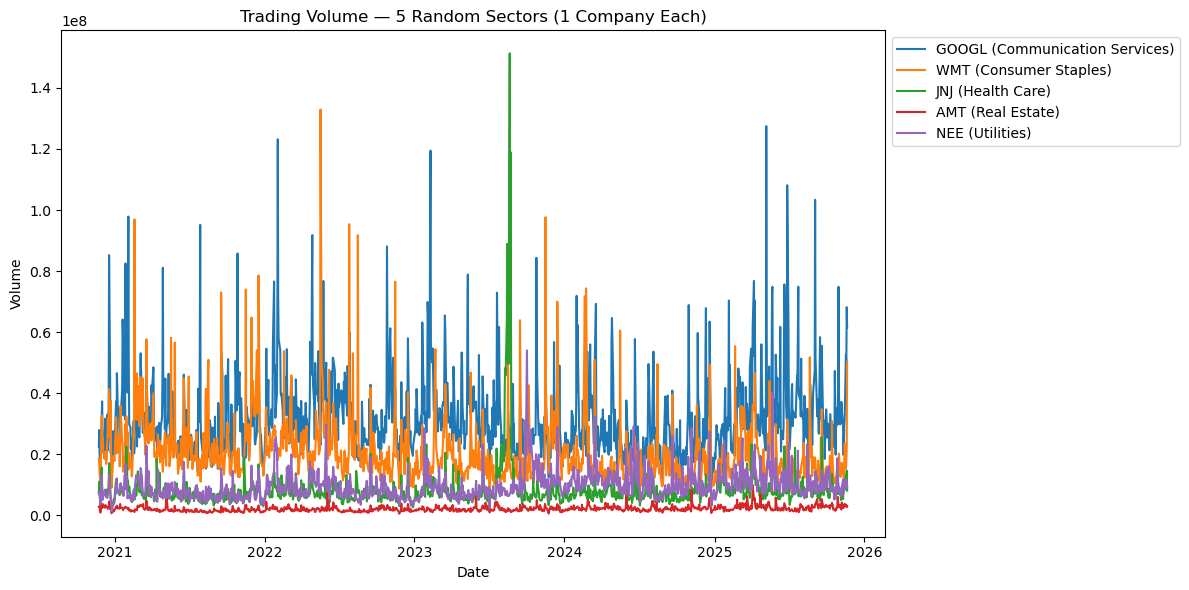

In [26]:
# Plot Volume

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Volume"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Trading Volume — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [27]:
# Calculate returns and standard deviations
import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])

# Calculate SD per stock
sd_return = sp500_subset2.groupby("Symbol")["Return"].std()
sd_logreturn = sp500_subset2.groupby("Symbol")["LogReturn"].std()

# Add to each row (same SD repeated per stock)
sp500_subset2["SD_Return"] = sp500_subset2["Symbol"].map(sd_return)
sp500_subset2["SD_LogReturn"] = sp500_subset2["Symbol"].map(sd_logreturn)

sp500_subset2[["Date", "Symbol", "Close", "Return", "LogReturn", "SD_Return", "SD_LogReturn"]]


,Date,Symbol,Close,Return,LogReturn,SD_Return,SD_LogReturn
6275,2020-11-23,AAPL,110.827545,NaN,NaN,0.017699,0.017634
6276,2020-11-24,AAPL,112.112503,0.011594,0.011528,0.017699,0.017634
6277,2020-11-25,AAPL,112.949669,0.007467,0.007439,0.017699,0.017634
6278,2020-11-27,AAPL,113.494804,0.004826,0.004815,0.017699,0.017634
6279,2020-11-30,AAPL,115.889488,0.021100,0.020880,0.017699,0.017634
...,...,...,...,...,...,...,...
16020,2025-11-14,XOM,119.290001,0.012993,0.012909,0.017331,0.017339
16021,2025-11-17,XOM,117.680000,-0.013497,-0.013588,0.017331,0.017339
16022,2025-11-18,XOM,119.029999,0.011472,0.011406,0.017331,0.017339
16023,2025-11-19,XOM,117.349998,-0.014114,-0.014215,0.017331,0.017339


In [28]:
import numpy as np
import pandas as pd

# Assign year and weights
sp500_subset2["Year"] = sp500_subset2["Date"].dt.year
year_weights = {2020: 0.10, 2021: 0.10, 2022: 0.10, 2023: 0.20, 2024: 0.30, 2025: 0.30}
sp500_subset2["YearWeight"] = sp500_subset2["Year"].map(year_weights).fillna(0)

# Weighted daily returns
weighted_summary = sp500_subset2.groupby("Symbol").apply(
    lambda df: pd.Series({
        "W_Daily_Return": np.average(df["Return"].dropna(), weights=df["YearWeight"].loc[df["Return"].notna()]),
        "W_Daily_LogReturn": np.average(df["LogReturn"].dropna(), weights=df["YearWeight"].loc[df["LogReturn"].notna()])
    })
).reset_index()

# Pull SD columns
sd_table = sp500_subset2.groupby("Symbol")[["SD_Return", "SD_LogReturn"]].first().reset_index()

# Merge SD into weighted returns
weighted_summary = weighted_summary.merge(sd_table, on="Symbol", how="left")

# Annualize weighted returns
weighted_summary["W_Annual_LogReturn"] = weighted_summary["W_Daily_LogReturn"] * 252
weighted_summary["W_Annual_Return"] = np.exp(weighted_summary["W_Annual_LogReturn"]) - 1

# Final table
weighted_summary = weighted_summary[[
    "Symbol",
    "W_Daily_Return",
    "W_Daily_LogReturn",
    "W_Annual_Return",
    "W_Annual_LogReturn",
    "SD_Return",
    "SD_LogReturn"
]]

weighted_summary


C:\Users\cynth\AppData\Local\Temp\ipykernel_11088\3595693568.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_summary = sp500_subset2.groupby("Symbol").apply(


,Symbol,W_Daily_Return,W_Daily_LogReturn,W_Annual_Return,W_Annual_LogReturn,SD_Return,SD_LogReturn
0,AAPL,0.000942,0.000792,0.220755,0.199470,0.017699,0.017634
1,ABBV,0.000894,0.000785,0.218818,0.197882,0.014111,0.014227
2,AMT,0.000005,-0.000125,-0.031072,-0.031565,0.016353,0.016341
3,AMZN,0.000895,0.000670,0.183960,0.168865,0.022128,0.022119
4,BRK-B,0.000710,0.000654,0.179136,0.164782,0.010881,0.010877
5,CAT,0.001290,0.001122,0.326867,0.282821,0.018370,0.018300
6,CEG,0.002671,0.002150,0.719080,0.541789,0.031012,0.030691
7,COP,0.000390,0.000193,0.049879,0.048675,0.021319,0.021361
8,COST,0.000889,0.000798,0.222629,0.201004,0.014150,0.014216
9,CVX,0.000424,0.000309,0.080926,0.077818,0.016143,0.016183


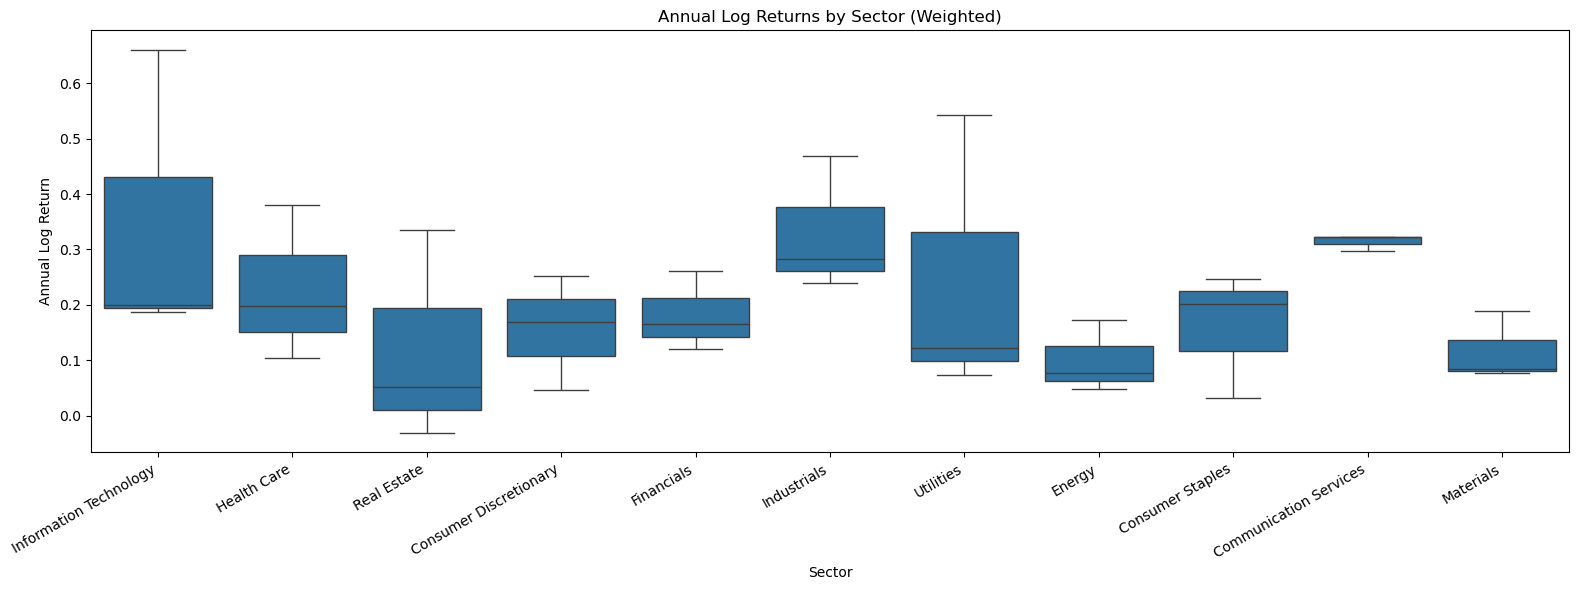

In [29]:
# Boxplot of annual log return by sector

import seaborn as sns
import matplotlib.pyplot as plt

# Attach Sector to weighted summary for boxplot
returns_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=returns_df, x="Sector", y="W_Annual_LogReturn")
plt.xticks(rotation=30, ha='right')
plt.title("Annual Log Returns by Sector (Weighted)")
plt.xlabel("Sector")
plt.ylabel("Annual Log Return")
plt.tight_layout()
plt.show()

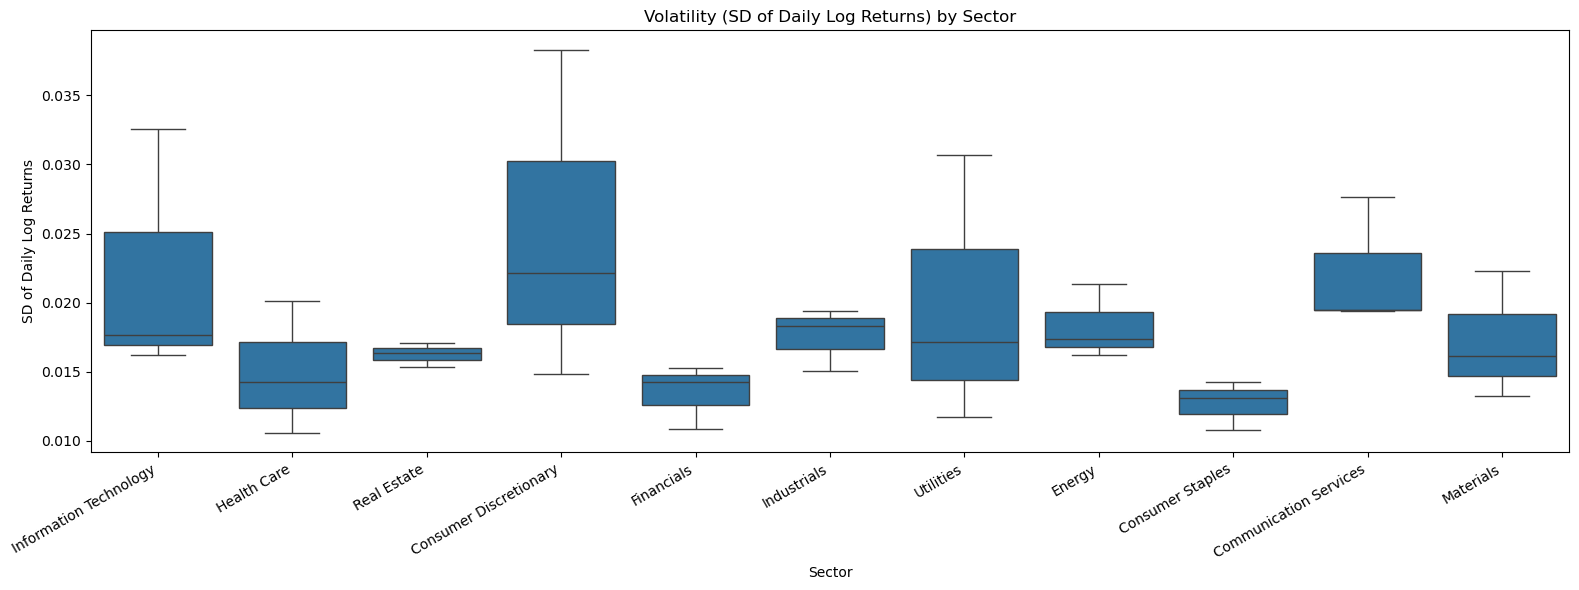

In [30]:
# Boxplot of volatility (SD of returns) by sector

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Sector column exists in weighted_summary
vol_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=vol_df, x="Sector", y="SD_LogReturn")
plt.xticks(rotation=30, ha='right')
plt.title("Volatility (SD of Daily Log Returns) by Sector")
plt.xlabel("Sector")
plt.ylabel("SD of Daily Log Returns")
plt.tight_layout()
plt.show()


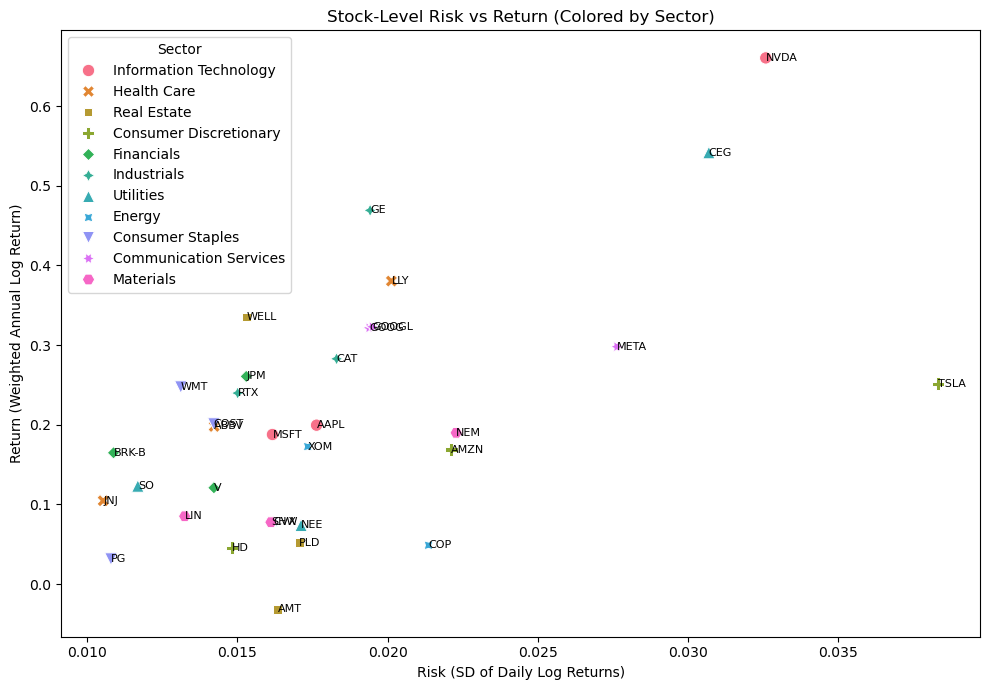

In [31]:
# Risk-Return Map By Stock

import seaborn as sns
import matplotlib.pyplot as plt

# Attach sector for coloring
df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="SD_LogReturn",
    y="W_Annual_LogReturn",
    hue="Sector",
    style="Sector",
    s=80
)

# Label each point with stock symbol
for _, row in df.iterrows():
    plt.text(
        row["SD_LogReturn"],
        row["W_Annual_LogReturn"],
        row["Symbol"],
        fontsize=8,
        ha='left',
        va='center'
    )

plt.xlabel("Risk (SD of Daily Log Returns)")
plt.ylabel("Return (Weighted Annual Log Return)")
plt.title("Stock-Level Risk vs Return (Colored by Sector)")
plt.tight_layout()
plt.show()


NEW CODE

In [32]:
# ============================================================
# NEW BLOCK: weighted_summary2
# Weighted Return + Weighted SD (timing-adjusted risk)
# ============================================================

def weighted_stats(df):
    # 1. Mask valid returns
    mask_r = df["Return"].notna()
    r = df.loc[mask_r, "Return"]
    wr = df.loc[mask_r, "YearWeight"]

    # Weighted mean (returns)
    w_mean_r = np.average(r, weights=wr)

    # Weighted variance & SD (returns)
    w_var_r = np.average((r - w_mean_r) ** 2, weights=wr)
    w_sd_r = np.sqrt(w_var_r)

    # 2. Weighted log returns
    mask_lr = df["LogReturn"].notna()
    lr = df.loc[mask_lr, "LogReturn"]
    wlr = df.loc[mask_lr, "YearWeight"]

    w_mean_lr = np.average(lr, weights=wlr)
    w_var_lr = np.average((lr - w_mean_lr) ** 2, weights=wlr)
    w_sd_lr = np.sqrt(w_var_lr)

    return pd.Series({
        "W_Daily_Return": w_mean_r,
        "W_Daily_LogReturn": w_mean_lr,
        "W_SD_Return": w_sd_r,
        "W_SD_LogReturn": w_sd_lr
    })

# Compute weighted mean + weighted SD for each stock
weighted_summary2 = sp500_subset2.groupby("Symbol").apply(weighted_stats).reset_index()

# Annualize weighted returns using weighted log-return
weighted_summary2["W_Annual_LogReturn"] = weighted_summary2["W_Daily_LogReturn"] * 252
weighted_summary2["W_Annual_Return"] = np.exp(weighted_summary2["W_Annual_LogReturn"]) - 1

# Annualize weighted SD (risk)
weighted_summary2["W_Annual_SD"] = weighted_summary2["W_SD_Return"] * np.sqrt(252)

# Reorder final table
weighted_summary2 = weighted_summary2[[
    "Symbol",
    "W_Daily_Return",
    "W_Daily_LogReturn",
    "W_Annual_Return",
    "W_Annual_LogReturn",
    "W_SD_Return",
    "W_SD_LogReturn",
    "W_Annual_SD"
]]

weighted_summary2


C:\Users\cynth\AppData\Local\Temp\ipykernel_11088\1267617791.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_summary2 = sp500_subset2.groupby("Symbol").apply(weighted_stats).reset_index()


,Symbol,W_Daily_Return,W_Daily_LogReturn,W_Annual_Return,W_Annual_LogReturn,W_SD_Return,W_SD_LogReturn,W_Annual_SD
0,AAPL,0.000942,0.000792,0.220755,0.199470,0.017378,0.017290,0.275861
1,ABBV,0.000894,0.000785,0.218818,0.197882,0.014606,0.014743,0.231869
2,AMT,0.000005,-0.000125,-0.031072,-0.031565,0.016158,0.016157,0.256498
3,AMZN,0.000895,0.000670,0.183960,0.168865,0.021234,0.021204,0.337073
4,BRK-B,0.000710,0.000654,0.179136,0.164782,0.010579,0.010582,0.167929
5,CAT,0.001290,0.001122,0.326867,0.282821,0.018331,0.018249,0.291000
6,CEG,0.002671,0.002150,0.719080,0.541789,0.032447,0.032107,0.515087
7,COP,0.000390,0.000193,0.049879,0.048675,0.019795,0.019854,0.314232
8,COST,0.000889,0.000798,0.222629,0.201004,0.013450,0.013499,0.213516
9,CVX,0.000424,0.000309,0.080926,0.077818,0.015167,0.015229,0.240772


In [34]:
# ============================================================
# EXPORT weighted_summary2 for optimization in VS Code
# ============================================================

mu_annual = weighted_summary2["W_Annual_Return"].values
sigma_annual = weighted_summary2["W_Annual_SD"].values
tickers = weighted_summary2["Symbol"].tolist()

np.save("mu_annual.npy", mu_annual)
np.save("sigma_annual.npy", sigma_annual)
pd.Series(tickers).to_csv("tickers.csv", index=False)

print("Exported: mu_annual.npy, sigma_annual.npy, tickers.csv")


Exported: mu_annual.npy, sigma_annual.npy, tickers.csv


In [38]:
print("Min weighted annual SD:", weighted_summary2["W_Annual_SD"].min())
print("Max weighted annual SD:", weighted_summary2["W_Annual_SD"].max())
print("Median weighted annual SD:", weighted_summary2["W_Annual_SD"].median())

Min weighted annual SD: 0.1677991128903937
Max weighted annual SD: 0.6175028196589601
Median weighted annual SD: 0.2511521800829071
